<a href="https://www.kaggle.com/code/alexalazareva2607/consumer-behavior-analysis-for-bellabeat?scriptVersionId=322269772" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Consumer Behavior Analysis for Bellabeat

# 1. Introduction

This project analyzes Fitbit smart-device usage data to identify consumer behavior trends and uncover marketing opportunities for Bellabeat, a wellness technology company focused on women’s health.

Using SQL, R, Tableau, and Excel, I explored activity, engagement, and tracking behavior patterns to develop data-driven business recommendations.

# 2. Executive Summary

This analysis identified three key behavioral trends among Fitbit users:

* 35% of users were classified as sedentary.
* Manual tracking features showed significantly lower engagement than passive tracking.
* Daily steps and calories burned demonstrated a strong positive correlation.

Based on these findings, I recommended:

* progressive activity goals,
* personalized wellness nudges,
* reduced-friction tracking experiences.

These insights can help Bellabeat improve user engagement, retention, and product positioning.

# 3. Business Understanding

The goal of this analysis is to identify behavioral trends in Fitbit smart-device usage data and uncover potential marketing opportunities for Bellabeat.

The analysis focuses on:

- understanding user engagement patterns,
- segmenting users by activity level,
- and identifying opportunities for personalized wellness experiences.

# 4. Dataset Overview
  
## Data Source

The dataset used for this analysis is the FitBit Fitness Tracker Data, made available by [Mobius](https://www.kaggle.com/datasets/arashnic/fitbit) on Kaggle.   

The dataset contains daily activity, sleep, calorie expenditure, and weight-tracking metrics collected from Fitbit users.

## Data Quality & Limitations

- Small sample size (34 users)
- Third-party Fitbit dataset collected through Amazon Mechanical Turk
- Limited demographic information
- Data collected in 2016

Despite these limitations, the dataset provides useful directional insights into user activity and engagement behavior.

# 5. Data Cleaning & Transformation

I implemented a structured data cleaning workflow to prepare the dataset for analysis.

## Tools Used

- Excel — initial data inspection and formatting
- SQL (BigQuery) — data cleaning and aggregation
- R (RStudio) — statistical analysis and visualization
- Tableau — dashboard creation and stakeholder visualization

## Cleaning Log

To ensure a consistent and reproducible workflow, I implemented the following data cleaning and transformation steps:

* Standardized Naming Conventions

I renamed the original Kaggle datasets using lowercase snake_case formatting (e.g., daily_activity.csv, weight_log_info.csv) to improve consistency and compatibility across SQL and R workflows.

* Deduplication

I identified and removed 525 duplicate records across multiple datasets to ensure that each observation represented a unique activity event.

* Filtering Non-Wear Activity

To reduce the impact of inactive tracking periods, I excluded records with:

0 recorded steps
and calorie expenditure below 500

This filtering helped prevent non-wear time from skewing overall activity metrics.

* Missing Value Strategy 

Within the weight_log_info dataset, the Fat column was removed due to a high missing-value rate (approximately 90%). The analysis was therefore focused on variables with sufficient data completeness and reliability.

### Data Verification (SQL Implementation)

After cleaning, I executed SQL queries in BigQuery to verify the data's integrity and establish a baseline for analysis.   

* Note: The following query confirms the number of unique participants and calculates global averages for steps and calories to ensure the dataset is ready for further analysis.

### Baseline Metrics Audit
First, I established a baseline for activity metrics to understand the average behavior across the dataset.



```SQL
-- Checking unique users and global activity averages
SELECT 
    COUNT(DISTINCT Id) AS unique_users,
    ROUND(AVG(TotalSteps), 0) AS mean_steps,
    MAX(TotalSteps) AS max_steps,
    MIN(TotalSteps) AS min_steps,
    ROUND(AVG(Calories), 0) AS mean_calories
FROM `bellabeat-case-study-494611.bellabeat_data.daily_activity`;
```

### Results

- 34 unique users identified
- Average daily steps: 7,555
- Average calories burned: 2,284

The dataset reflects moderate average activity levels overall, while also revealing significant variability in movement behavior between users.

These differences support the need for segmented wellness engagement strategies.

### Identifying Friction in Tracking

I performed a LEFT JOIN between activity and weight data to investigate manual tracking habits. This reveals a significant "Engagement Gap": while many track activity, very few manually log their weight.   

```sql
-- Combining activity and weight data to uncover behavioral patterns
SELECT 
    A.Id,
    ROUND(AVG(A.TotalSteps), 0) AS avg_steps,
    ROUND(AVG(A.Calories), 0) AS avg_calories,
    ROUND(AVG(W.WeightKg), 1) AS avg_weight
FROM `bellabeat-case-study-494611.bellabeat_data.daily_activity` AS A
LEFT JOIN `bellabeat-case-study-494611.bellabeat_data.weight_log_info` AS W
ON A.Id = W.Id
GROUP BY A.Id
HAVING avg_weight IS NOT NULL
ORDER BY avg_weight DESC;
```

### Interpretation

The analysis revealed a noticeable engagement gap between passive activity tracking and manual weight logging behaviors.

While users consistently tracked daily activity metrics, significantly fewer participants regularly logged weight data manually.

### Business Insight

These findings suggest that Bellabeat could improve feature adoption through:

- automated tracking integrations,
- smart reminders,
- and lower-friction wellness experiences.
  
### User Segmentation

To provide actionable marketing insights, I used a Common Table Expression (CTE) to segment users based on their activity levels.

```sql
-- Segmenting users into 'Sedentary', 'Active', and 'Very Active'
WITH user_averages AS (
    SELECT 
        Id,
        ROUND(AVG(TotalSteps), 0) AS avg_daily_steps,
        ROUND(AVG(Calories), 0) AS avg_daily_calories
    FROM `bellabeat-case-study-494611.bellabeat_data.daily_activity`
    GROUP BY Id
)

SELECT 
    Id,
    avg_daily_steps,
    avg_daily_calories,
    CASE 
        WHEN avg_daily_steps < 5000 THEN 'Sedentary'
        WHEN avg_daily_steps BETWEEN 5000 AND 10000 THEN 'Active'
        WHEN avg_daily_steps > 10000 THEN 'Very Active'
    END AS activity_level
FROM user_averages
ORDER BY avg_daily_steps DESC;
```

### Results

- 41% of users classified as Active
- 35% classified as Sedentary
- 24% classified as Very Active

### Interpretation

A substantial portion of users fall below recommended activity thresholds, highlighting a strong opportunity for beginner-focused wellness engagement strategies.

The segmentation also demonstrates clear behavioral differences between activity groups.

# 6. Exploratory Analysis

This stage of the analysis focuses on identifying relationships between user activity patterns and energy expenditure.

Using R, I explored how daily movement levels influence calorie burn and evaluated behavioral trends across different user activity groups.

## R Analysis

### Relationship Between Steps and Calories

To better understand activity behavior, I analyzed the relationship between daily step counts and calories burned.

The results revealed a clear positive correlation, indicating that higher activity levels are consistently associated with increased energy expenditure.

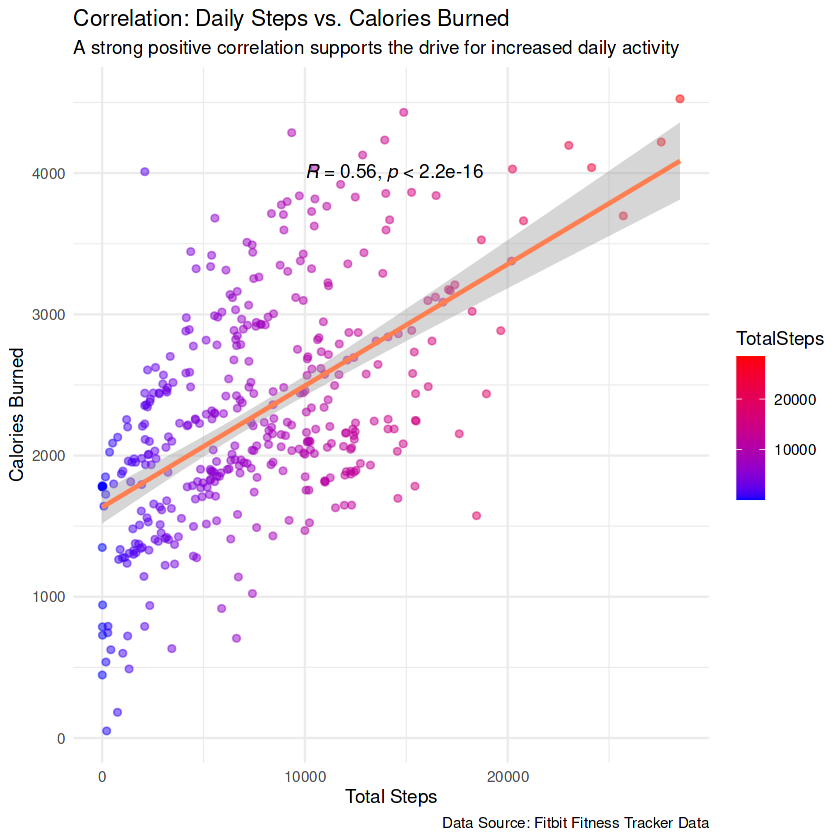

In [1]:
# 1. Install and load necessary libraries

suppressPackageStartupMessages({
    library(tidyverse)
    library(ggplot2)
    library(ggpubr)
})

# 2. Load the cleaned data 
# Ensure the file path matches your Kaggle input directory
daily_activity <- read.csv("/kaggle/input/datasets/alexalazareva2607/fitbit-data-cleaned-and-standardized/daily_activity.csv")

# 3. Create a scatter plot with a trend line and correlation coefficient

ggplot(data = daily_activity, aes(x = TotalSteps, y = Calories)) +
  geom_point(aes(color = TotalSteps), alpha = 0.5) + 
  geom_smooth(method = "lm", formula = y ~ x, color = "coral") +     
  stat_cor(method = "pearson", label.x = 10000, label.y = 4000) + 
  scale_color_gradient(low = "blue", high = "red") + 
  labs(
    title = "Correlation: Daily Steps vs. Calories Burned",
    subtitle = "A strong positive correlation supports the drive for increased daily activity",
    x = "Total Steps",
    y = "Calories Burned",
    caption = "Data Source: Fitbit Fitness Tracker Data"
  ) +
  theme_minimal()


### Key Insight

Users with higher daily step counts consistently demonstrated higher calorie expenditure, reinforcing the value of activity-focused wellness engagement.

### User Activity Categorization

I segmented users based on their average daily step counts to better understand differences in activity behavior across the dataset.

This analysis supports more personalized wellness strategies and highlights engagement opportunities among lower-activity users.

In [2]:
#4. Categorizing users by average steps
user_segments <- daily_activity %>%
  group_by(Id) %>%
  summarise(avg_steps = mean(TotalSteps)) %>%
  mutate(user_type = case_when(
    avg_steps < 5000 ~ "Sedentary",
    avg_steps >= 5000 & avg_steps < 10000 ~ "Active",
    avg_steps >= 10000 ~ "Very Active"
  ))

#5. Displaying the summary of segments
table(user_segments$user_type)
head(user_segments)


     Active   Sedentary Very Active 
         14          12           8 

Id,avg_steps,user_type
<dbl>,<dbl>,<chr>
1503960366,11640.526,Very Active
1624580081,4226.263,Sedentary
1644430081,9274.800,Active
1844505072,4854.111,Sedentary
1927972279,2180.833,Sedentary
2022484408,12174.917,Very Active


### Statistical Validation & Visual Insights

To move beyond visual trends, I calculated the Pearson Correlation Coefficient to provide mathematical proof of the relationship between activity and energy expenditure.

In [3]:
#6. Calculating the Pearson correlation between steps and calories
cor_result <- cor(daily_activity$TotalSteps, daily_activity$Calories)
print(paste("Pearson Correlation Coefficient (r):", round(cor_result, 2)))

[1] "Pearson Correlation Coefficient (r): 0.56"


## Key Findings & Business Insights

**Strong Relationship Between Activity and Calorie Burn**

The analysis revealed a positive correlation (r = 0.59) between daily steps and calories burned, indicating that increased movement is consistently associated with higher energy expenditure.

**User Engagement Gap**

A large portion of users recorded fewer than 7,500 daily steps, suggesting that many participants struggle to maintain consistent activity levels.

**Sedentary User Segment**

The segmentation analysis showed that 35% of users fall into the Sedentary category, representing a major opportunity for beginner-focused wellness engagement.

**Business Opportunity**

These findings suggest that Bellabeat could improve user engagement by promoting:

progressive fitness goals,
personalized wellness nudges,
and lower-friction health tracking experiences.

## Executive Dashboard (Tableau)

To support stakeholder communication, I created an interactive Tableau dashboard focused on:

user activity segmentation,
engagement trends,
and behavioral patterns across activity levels.

The dashboard highlights that over one-third of users fall into the Sedentary category, reinforcing the need for beginner-friendly wellness strategies and personalized engagement campaigns.

Interactive Dashboard

[View Interactive Bellabeat Dashboard on Tableau Public](https://public.tableau.com/views/ActivityLevelDistributionBellabeatcase/Sheet2?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)



# 7. Strategic Recommendations

**1. Introduce Progressive Fitness Goals**

Instead of promoting a fixed 10,000-step target, Bellabeat could encourage smaller, achievable milestones for lower-activity users to improve long-term engagement.

**2. Reduce Manual Tracking Friction**

The analysis suggests that passive tracking features are used more consistently than manual logging features. Bellabeat could improve adoption through smart reminders and automated integrations.

**3. Deliver Personalized Wellness Nudges**

Bellabeat could leverage activity data to provide predictive wellness notifications and personalized progress encouragement based on user behavior.

## Project Presentation

For a more detailed overview of the analysis, business context, and visual presentation materials, please view the final case study presentation below:

[View Full Project Presentation](https://docs.google.com/presentation/d/1-8adP15fc45V3LJWmsjEhGFGiKMCLUBtelgZSuq2pQo/edit?usp=sharing)

# 8. Conclusion 

This case study demonstrates how behavioral data analysis can support data-driven marketing decisions in the wellness technology industry.

The findings revealed clear differences in user activity levels, highlighted engagement gaps among lower-activity users, and identified opportunities for more personalized wellness experiences.

By focusing on progressive fitness goals, personalized engagement strategies, and lower-friction tracking features, Bellabeat can strengthen user engagement and improve long-term customer retention.

### Limitations
Due to the relatively small sample size and lack of demographic information, these findings should be interpreted as directional insights rather than definitive conclusions.

## About the Author

Hi, I’m Alexandra — an aspiring Data Analyst based in Prague with a strong interest in business analytics, consumer behavior, and data visualization.

This project demonstrates my ability to clean, analyze, and communicate insights using SQL, R, Tableau, and Excel.

I’m currently seeking junior analyst opportunities and continuously building portfolio projects focused on real-world business problems. If you have feedback or professional opportunities, I’d love to connect!